In [0]:
customers_df = spark.read \
.option("header","true") \
.option("inferSchema","true") \
.csv("/Volumes/ey_data/default/data/customers.csv")

display(customers_df)

customers_df.printSchema()

customer_id,customer_name,city,state,customer_type
C101,Rahul Sharma,Hyderabad,Telangana,Premium
C102,Priya Reddy,Bangalore,Karnataka,Regular
C103,Amit Kumar,Mumbai,Maharashtra,Regular
C104,Sneha Patel,Delhi,Delhi,Premium
C105,Farhan Ali,Chennai,Tamil Nadu,Regular
C106,Neha Singh,Pune,Maharashtra,Premium
C107,Arjun Verma,Hyderabad,Telangana,Regular
C108,Meera Nair,Kochi,Kerala,Premium


root
 |-- customer_id: string (nullable = true)
 |-- customer_name: string (nullable = true)
 |-- city: string (nullable = true)
 |-- state: string (nullable = true)
 |-- customer_type: string (nullable = true)



In [0]:
products_df = spark.read \
.option("header","true") \
.option("inferSchema","true") \
.csv("/Volumes/ey_data/default/data/products.csv")

display(products_df)

products_df.printSchema()

product_id,product_name,category,unit_price
P101,Laptop,Electronics,65000
P102,Mobile,Electronics,25000
P103,Chair,Furniture,7000
P104,Table,Furniture,12000
P105,Shoes,Fashion,4500
P106,Watch,Fashion,8000
P107,TV,Electronics,45000
P108,Bag,Fashion,3000


root
 |-- product_id: string (nullable = true)
 |-- product_name: string (nullable = true)
 |-- category: string (nullable = true)
 |-- unit_price: integer (nullable = true)



In [0]:
orders_df = spark.read \
.option("header","true") \
.option("inferSchema","true") \
.csv("/Volumes/ey_data/default/data/orders.csv")

display(orders_df)

orders_df.printSchema()

order_id,customer_id,product_id,order_date,quantity,status
O1001,C101,P101,2026-06-01,1,Completed
O1002,C102,P102,2026-06-01,2,Completed
O1003,C103,P103,2026-06-02,3,Pending
O1004,C104,P104,2026-06-02,2,Completed
O1005,C105,P105,2026-06-03,4,Cancelled
O1006,C106,P106,2026-06-03,1,Completed
O1007,C107,P107,2026-06-04,1,Completed
O1008,C108,P108,2026-06-04,5,Completed
O1009,C101,P102,2026-06-05,1,Completed
O1010,C104,P101,2026-06-05,1,Completed


root
 |-- order_id: string (nullable = true)
 |-- customer_id: string (nullable = true)
 |-- product_id: string (nullable = true)
 |-- order_date: date (nullable = true)
 |-- quantity: integer (nullable = true)
 |-- status: string (nullable = true)



In [0]:
preferences_df = spark.read \
.option("multiLine","true") \
.json("/Volumes/ey_data/default/data/customer_preferences.json")

display(preferences_df)

preferences_df.printSchema()

customer_id,loyalty,preferred_channel
C101,"List(1200, Gold)",Online
C102,"List(700, Silver)",Store
C104,"List(2200, Platinum)",Online
C108,"List(1500, Gold)",Mobile App


root
 |-- customer_id: string (nullable = true)
 |-- loyalty: struct (nullable = true)
 |    |-- points: long (nullable = true)
 |    |-- tier: string (nullable = true)
 |-- preferred_channel: string (nullable = true)



In [0]:
customers_df.write \
.format("delta") \
.mode("overwrite") \
.saveAsTable("bronze_customers")

In [0]:
products_df.write \
.format("delta") \
.mode("overwrite") \
.saveAsTable("bronze_products")

In [0]:
orders_df.write \
.format("delta") \
.mode("overwrite") \
.saveAsTable("bronze_orders")

In [0]:
preferences_df.write \
.format("delta") \
.mode("overwrite") \
.saveAsTable("bronze_preference")

In [0]:
display(spark.sql("SHOW TABLES"))

database,tableName,isTemporary
default,bronze_appointments,false
default,bronze_customers,false
default,bronze_doctors,false
default,bronze_orders,false
default,bronze_patients,false
default,bronze_preference,false
default,bronze_preferences,false
default,bronze_products,false
default,external_healthcare,false
default,healthcare_master,false


In [0]:
from pyspark.sql.functions import *

In [0]:
customers_df = customers_df.fillna("Unknown")

products_df = products_df.fillna("Unknown")

orders_df = orders_df.fillna({
    "quantity":0,
    "status":"Pending"
})

In [0]:
preferences_flat = preferences_df.select(
    "customer_id",
    "preferred_channel",
    col("loyalty.tier").alias("tier"),
    col("loyalty.points").alias("points")
)

display(preferences_flat)

customer_id,preferred_channel,tier,points
C101,Online,Gold,1200
C102,Store,Silver,700
C104,Online,Platinum,2200
C108,Mobile App,Gold,1500


In [0]:
customer_pref = customers_df.join(
    preferences_flat,
    "customer_id",
    "left"
)

display(customer_pref)

customer_id,customer_name,city,state,customer_type,preferred_channel,tier,points
C101,Rahul Sharma,Hyderabad,Telangana,Premium,Online,Gold,1200
C102,Priya Reddy,Bangalore,Karnataka,Regular,Store,Silver,700
C103,Amit Kumar,Mumbai,Maharashtra,Regular,null,null,null
C104,Sneha Patel,Delhi,Delhi,Premium,Online,Platinum,2200
C105,Farhan Ali,Chennai,Tamil Nadu,Regular,null,null,null
C106,Neha Singh,Pune,Maharashtra,Premium,null,null,null
C107,Arjun Verma,Hyderabad,Telangana,Regular,null,null,null
C108,Meera Nair,Kochi,Kerala,Premium,Mobile App,Gold,1500


In [0]:
order_customer = orders_df.join(
    customers_df,
    "customer_id",
    "inner"
)

display(order_customer)

customer_id,order_id,product_id,order_date,quantity,status,customer_name,city,state,customer_type
C101,O1001,P101,2026-06-01,1,Completed,Rahul Sharma,Hyderabad,Telangana,Premium
C102,O1002,P102,2026-06-01,2,Completed,Priya Reddy,Bangalore,Karnataka,Regular
C103,O1003,P103,2026-06-02,3,Pending,Amit Kumar,Mumbai,Maharashtra,Regular
C104,O1004,P104,2026-06-02,2,Completed,Sneha Patel,Delhi,Delhi,Premium
C105,O1005,P105,2026-06-03,4,Cancelled,Farhan Ali,Chennai,Tamil Nadu,Regular
C106,O1006,P106,2026-06-03,1,Completed,Neha Singh,Pune,Maharashtra,Premium
C107,O1007,P107,2026-06-04,1,Completed,Arjun Verma,Hyderabad,Telangana,Regular
C108,O1008,P108,2026-06-04,5,Completed,Meera Nair,Kochi,Kerala,Premium
C101,O1009,P102,2026-06-05,1,Completed,Rahul Sharma,Hyderabad,Telangana,Premium
C104,O1010,P101,2026-06-05,1,Completed,Sneha Patel,Delhi,Delhi,Premium


In [0]:
retail_df = order_customer.join(
    products_df,
    "product_id",
    "inner"
)

display(retail_df)

product_id,customer_id,order_id,order_date,quantity,status,customer_name,city,state,customer_type,product_name,category,unit_price
P101,C101,O1001,2026-06-01,1,Completed,Rahul Sharma,Hyderabad,Telangana,Premium,Laptop,Electronics,65000
P102,C102,O1002,2026-06-01,2,Completed,Priya Reddy,Bangalore,Karnataka,Regular,Mobile,Electronics,25000
P103,C103,O1003,2026-06-02,3,Pending,Amit Kumar,Mumbai,Maharashtra,Regular,Chair,Furniture,7000
P104,C104,O1004,2026-06-02,2,Completed,Sneha Patel,Delhi,Delhi,Premium,Table,Furniture,12000
P105,C105,O1005,2026-06-03,4,Cancelled,Farhan Ali,Chennai,Tamil Nadu,Regular,Shoes,Fashion,4500
P106,C106,O1006,2026-06-03,1,Completed,Neha Singh,Pune,Maharashtra,Premium,Watch,Fashion,8000
P107,C107,O1007,2026-06-04,1,Completed,Arjun Verma,Hyderabad,Telangana,Regular,TV,Electronics,45000
P108,C108,O1008,2026-06-04,5,Completed,Meera Nair,Kochi,Kerala,Premium,Bag,Fashion,3000
P102,C101,O1009,2026-06-05,1,Completed,Rahul Sharma,Hyderabad,Telangana,Premium,Mobile,Electronics,25000
P101,C104,O1010,2026-06-05,1,Completed,Sneha Patel,Delhi,Delhi,Premium,Laptop,Electronics,65000


In [0]:
retail_df = retail_df.withColumn(
    "revenue",
    col("quantity") * col("unit_price")
)

display(retail_df)

product_id,customer_id,order_id,order_date,quantity,status,customer_name,city,state,customer_type,product_name,category,unit_price,revenue
P101,C101,O1001,2026-06-01,1,Completed,Rahul Sharma,Hyderabad,Telangana,Premium,Laptop,Electronics,65000,65000
P102,C102,O1002,2026-06-01,2,Completed,Priya Reddy,Bangalore,Karnataka,Regular,Mobile,Electronics,25000,50000
P103,C103,O1003,2026-06-02,3,Pending,Amit Kumar,Mumbai,Maharashtra,Regular,Chair,Furniture,7000,21000
P104,C104,O1004,2026-06-02,2,Completed,Sneha Patel,Delhi,Delhi,Premium,Table,Furniture,12000,24000
P105,C105,O1005,2026-06-03,4,Cancelled,Farhan Ali,Chennai,Tamil Nadu,Regular,Shoes,Fashion,4500,18000
P106,C106,O1006,2026-06-03,1,Completed,Neha Singh,Pune,Maharashtra,Premium,Watch,Fashion,8000,8000
P107,C107,O1007,2026-06-04,1,Completed,Arjun Verma,Hyderabad,Telangana,Regular,TV,Electronics,45000,45000
P108,C108,O1008,2026-06-04,5,Completed,Meera Nair,Kochi,Kerala,Premium,Bag,Fashion,3000,15000
P102,C101,O1009,2026-06-05,1,Completed,Rahul Sharma,Hyderabad,Telangana,Premium,Mobile,Electronics,25000,25000
P101,C104,O1010,2026-06-05,1,Completed,Sneha Patel,Delhi,Delhi,Premium,Laptop,Electronics,65000,65000


In [0]:
retail_df = retail_df.withColumn(
    "order_month",
    month("order_date")
)

display(retail_df)

product_id,customer_id,order_id,order_date,quantity,status,customer_name,city,state,customer_type,product_name,category,unit_price,revenue,order_month
P101,C101,O1001,2026-06-01,1,Completed,Rahul Sharma,Hyderabad,Telangana,Premium,Laptop,Electronics,65000,65000,6
P102,C102,O1002,2026-06-01,2,Completed,Priya Reddy,Bangalore,Karnataka,Regular,Mobile,Electronics,25000,50000,6
P103,C103,O1003,2026-06-02,3,Pending,Amit Kumar,Mumbai,Maharashtra,Regular,Chair,Furniture,7000,21000,6
P104,C104,O1004,2026-06-02,2,Completed,Sneha Patel,Delhi,Delhi,Premium,Table,Furniture,12000,24000,6
P105,C105,O1005,2026-06-03,4,Cancelled,Farhan Ali,Chennai,Tamil Nadu,Regular,Shoes,Fashion,4500,18000,6
P106,C106,O1006,2026-06-03,1,Completed,Neha Singh,Pune,Maharashtra,Premium,Watch,Fashion,8000,8000,6
P107,C107,O1007,2026-06-04,1,Completed,Arjun Verma,Hyderabad,Telangana,Regular,TV,Electronics,45000,45000,6
P108,C108,O1008,2026-06-04,5,Completed,Meera Nair,Kochi,Kerala,Premium,Bag,Fashion,3000,15000,6
P102,C101,O1009,2026-06-05,1,Completed,Rahul Sharma,Hyderabad,Telangana,Premium,Mobile,Electronics,25000,25000,6
P101,C104,O1010,2026-06-05,1,Completed,Sneha Patel,Delhi,Delhi,Premium,Laptop,Electronics,65000,65000,6


In [0]:
retail_df = retail_df.withColumn(
    "customer_segment",
    when(col("customer_type") == "Premium", "High Value")
    .otherwise("Standard Value")
)

display(retail_df)

product_id,customer_id,order_id,order_date,quantity,status,customer_name,city,state,customer_type,product_name,category,unit_price,revenue,order_month,customer_segment
P101,C101,O1001,2026-06-01,1,Completed,Rahul Sharma,Hyderabad,Telangana,Premium,Laptop,Electronics,65000,65000,6,High Value
P102,C102,O1002,2026-06-01,2,Completed,Priya Reddy,Bangalore,Karnataka,Regular,Mobile,Electronics,25000,50000,6,Standard Value
P103,C103,O1003,2026-06-02,3,Pending,Amit Kumar,Mumbai,Maharashtra,Regular,Chair,Furniture,7000,21000,6,Standard Value
P104,C104,O1004,2026-06-02,2,Completed,Sneha Patel,Delhi,Delhi,Premium,Table,Furniture,12000,24000,6,High Value
P105,C105,O1005,2026-06-03,4,Cancelled,Farhan Ali,Chennai,Tamil Nadu,Regular,Shoes,Fashion,4500,18000,6,Standard Value
P106,C106,O1006,2026-06-03,1,Completed,Neha Singh,Pune,Maharashtra,Premium,Watch,Fashion,8000,8000,6,High Value
P107,C107,O1007,2026-06-04,1,Completed,Arjun Verma,Hyderabad,Telangana,Regular,TV,Electronics,45000,45000,6,Standard Value
P108,C108,O1008,2026-06-04,5,Completed,Meera Nair,Kochi,Kerala,Premium,Bag,Fashion,3000,15000,6,High Value
P102,C101,O1009,2026-06-05,1,Completed,Rahul Sharma,Hyderabad,Telangana,Premium,Mobile,Electronics,25000,25000,6,High Value
P101,C104,O1010,2026-06-05,1,Completed,Sneha Patel,Delhi,Delhi,Premium,Laptop,Electronics,65000,65000,6,High Value


In [0]:
customer_pref.write \
.format("delta") \
.mode("overwrite") \
.saveAsTable("silver_customers")

In [0]:
products_df.write \
.format("delta") \
.mode("overwrite") \
.saveAsTable("silver_products")

In [0]:
orders_df.write \
.format("delta") \
.mode("overwrite") \
.saveAsTable("silver_orders")

In [0]:
retail_df.write \
.format("delta") \
.mode("overwrite") \
.saveAsTable("silver_retail")

In [0]:
retail_df.createOrReplaceTempView("retail")

In [0]:

%sql
SELECT
SUM(revenue) AS Total_Revenue
FROM retail;

Total_Revenue
336000


In [0]:
%sql
SELECT
city,
SUM(revenue) AS Revenue
FROM retail
GROUP BY city
ORDER BY Revenue DESC;

city,Revenue
Hyderabad,135000
Delhi,89000
Bangalore,50000
Mumbai,21000
Chennai,18000
Kochi,15000
Pune,8000


In [0]:
%sql
SELECT
category,
SUM(revenue) AS Revenue
FROM retail
GROUP BY category
ORDER BY Revenue DESC;

category,Revenue
Electronics,250000
Furniture,45000
Fashion,41000


In [0]:
%sql
SELECT
customer_name,
SUM(revenue) AS Total_Revenue
FROM retail
GROUP BY customer_name
ORDER BY Total_Revenue DESC
LIMIT 5;

customer_name,Total_Revenue
Rahul Sharma,90000
Sneha Patel,89000
Priya Reddy,50000
Arjun Verma,45000
Amit Kumar,21000


In [0]:
%sql
SELECT *
FROM retail
WHERE status='Completed';

product_id,customer_id,order_id,order_date,quantity,status,customer_name,city,state,customer_type,product_name,category,unit_price,revenue,order_month,customer_segment
P101,C101,O1001,2026-06-01,1,Completed,Rahul Sharma,Hyderabad,Telangana,Premium,Laptop,Electronics,65000,65000,6,High Value
P102,C102,O1002,2026-06-01,2,Completed,Priya Reddy,Bangalore,Karnataka,Regular,Mobile,Electronics,25000,50000,6,Standard Value
P104,C104,O1004,2026-06-02,2,Completed,Sneha Patel,Delhi,Delhi,Premium,Table,Furniture,12000,24000,6,High Value
P106,C106,O1006,2026-06-03,1,Completed,Neha Singh,Pune,Maharashtra,Premium,Watch,Fashion,8000,8000,6,High Value
P107,C107,O1007,2026-06-04,1,Completed,Arjun Verma,Hyderabad,Telangana,Regular,TV,Electronics,45000,45000,6,Standard Value
P108,C108,O1008,2026-06-04,5,Completed,Meera Nair,Kochi,Kerala,Premium,Bag,Fashion,3000,15000,6,High Value
P102,C101,O1009,2026-06-05,1,Completed,Rahul Sharma,Hyderabad,Telangana,Premium,Mobile,Electronics,25000,25000,6,High Value
P101,C104,O1010,2026-06-05,1,Completed,Sneha Patel,Delhi,Delhi,Premium,Laptop,Electronics,65000,65000,6,High Value


In [0]:
from pyspark.sql.window import Window
from pyspark.sql.functions import *

In [0]:
product_revenue = retail_df.groupBy(
    "product_name"
).agg(
    sum("revenue").alias("Revenue")
)

windowSpec = Window.orderBy(desc("Revenue"))

product_rank = product_revenue.withColumn(
    "Rank",
    rank().over(windowSpec)
)

display(product_rank)

/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1160: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(
/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1160: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


product_name,Revenue,Rank
Laptop,130000,1
Mobile,75000,2
TV,45000,3
Table,24000,4
Chair,21000,5
Shoes,18000,6
Bag,15000,7
Watch,8000,8


In [0]:
customer_revenue = retail_df.groupBy(
    "customer_name"
).agg(
    sum("revenue").alias("Revenue")
)

windowSpec = Window.orderBy(desc("Revenue"))

customer_rank = customer_revenue.withColumn(
    "Rank",
    rank().over(windowSpec)
)

display(customer_rank)

/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1160: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


customer_name,Revenue,Rank
Rahul Sharma,90000,1
Sneha Patel,89000,2
Priya Reddy,50000,3
Arjun Verma,45000,4
Amit Kumar,21000,5
Farhan Ali,18000,6
Meera Nair,15000,7
Neha Singh,8000,8


In [0]:
top_customers = customer_revenue.withColumn(
    "Rank",
    dense_rank().over(Window.orderBy(desc("Revenue")))
).filter(col("Rank") <= 3)

display(top_customers)

/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1160: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


customer_name,Revenue,Rank
Rahul Sharma,90000,1
Sneha Patel,89000,2
Priya Reddy,50000,3


In [0]:
category_product = retail_df.groupBy(
    "category",
    "product_name"
).agg(
    sum("revenue").alias("Revenue")
)

windowSpec = Window.partitionBy("category").orderBy(desc("Revenue"))

top_product = category_product.withColumn(
    "Rank",
    row_number().over(windowSpec)
).filter(col("Rank") == 1)

display(top_product)

category,product_name,Revenue,Rank
Electronics,Laptop,130000,1
Fashion,Shoes,18000,1
Furniture,Table,24000,1


In [0]:
daily_revenue = retail_df.groupBy(
    "order_date"
).agg(
    sum("revenue").alias("Revenue")
)

windowSpec = Window.orderBy("order_date")

running_revenue = daily_revenue.withColumn(
    "Running_Revenue",
    sum("Revenue").over(windowSpec)
)

display(running_revenue)

/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1160: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


order_date,Revenue,Running_Revenue
2026-06-01,115000,115000
2026-06-02,45000,160000
2026-06-03,26000,186000
2026-06-04,60000,246000
2026-06-05,90000,336000


In [0]:
retail_df.write \
.format("delta") \
.mode("overwrite") \
.save("/tmp/retail_delta")

In [0]:
delta_df = spark.read \
.format("delta") \
.load("/tmp/retail_delta")

display(delta_df)

product_id,customer_id,order_id,order_date,quantity,status,customer_name,city,state,customer_type,product_name,category,unit_price,revenue,order_month,customer_segment
P101,C101,O1001,2026-06-01,1,Completed,Rahul Sharma,Hyderabad,Telangana,Premium,Laptop,Electronics,65000,65000,6,High Value
P102,C102,O1002,2026-06-01,2,Completed,Priya Reddy,Bangalore,Karnataka,Regular,Mobile,Electronics,25000,50000,6,Standard Value
P103,C103,O1003,2026-06-02,3,Pending,Amit Kumar,Mumbai,Maharashtra,Regular,Chair,Furniture,7000,21000,6,Standard Value
P104,C104,O1004,2026-06-02,2,Completed,Sneha Patel,Delhi,Delhi,Premium,Table,Furniture,12000,24000,6,High Value
P105,C105,O1005,2026-06-03,4,Cancelled,Farhan Ali,Chennai,Tamil Nadu,Regular,Shoes,Fashion,4500,18000,6,Standard Value
P106,C106,O1006,2026-06-03,1,Completed,Neha Singh,Pune,Maharashtra,Premium,Watch,Fashion,8000,8000,6,High Value
P107,C107,O1007,2026-06-04,1,Completed,Arjun Verma,Hyderabad,Telangana,Regular,TV,Electronics,45000,45000,6,Standard Value
P108,C108,O1008,2026-06-04,5,Completed,Meera Nair,Kochi,Kerala,Premium,Bag,Fashion,3000,15000,6,High Value
P102,C101,O1009,2026-06-05,1,Completed,Rahul Sharma,Hyderabad,Telangana,Premium,Mobile,Electronics,25000,25000,6,High Value
P101,C104,O1010,2026-06-05,1,Completed,Sneha Patel,Delhi,Delhi,Premium,Laptop,Electronics,65000,65000,6,High Value


In [0]:
retail_df.write \
.format("delta") \
.mode("overwrite") \
.saveAsTable("retail_master")

In [0]:
%sql
CREATE TABLE retail_sql
USING DELTA
AS
SELECT * FROM retail_master;

num_affected_rows,num_inserted_rows


In [0]:
%sql
SELECT * FROM retail_sql;

product_id,customer_id,order_id,order_date,quantity,status,customer_name,city,state,customer_type,product_name,category,unit_price,revenue,order_month,customer_segment
P101,C101,O1001,2026-06-01,1,Completed,Rahul Sharma,Hyderabad,Telangana,Premium,Laptop,Electronics,65000,65000,6,High Value
P102,C102,O1002,2026-06-01,2,Completed,Priya Reddy,Bangalore,Karnataka,Regular,Mobile,Electronics,25000,50000,6,Standard Value
P103,C103,O1003,2026-06-02,3,Pending,Amit Kumar,Mumbai,Maharashtra,Regular,Chair,Furniture,7000,21000,6,Standard Value
P104,C104,O1004,2026-06-02,2,Completed,Sneha Patel,Delhi,Delhi,Premium,Table,Furniture,12000,24000,6,High Value
P105,C105,O1005,2026-06-03,4,Cancelled,Farhan Ali,Chennai,Tamil Nadu,Regular,Shoes,Fashion,4500,18000,6,Standard Value
P106,C106,O1006,2026-06-03,1,Completed,Neha Singh,Pune,Maharashtra,Premium,Watch,Fashion,8000,8000,6,High Value
P107,C107,O1007,2026-06-04,1,Completed,Arjun Verma,Hyderabad,Telangana,Regular,TV,Electronics,45000,45000,6,Standard Value
P108,C108,O1008,2026-06-04,5,Completed,Meera Nair,Kochi,Kerala,Premium,Bag,Fashion,3000,15000,6,High Value
P102,C101,O1009,2026-06-05,1,Completed,Rahul Sharma,Hyderabad,Telangana,Premium,Mobile,Electronics,25000,25000,6,High Value
P101,C104,O1010,2026-06-05,1,Completed,Sneha Patel,Delhi,Delhi,Premium,Laptop,Electronics,65000,65000,6,High Value


In [0]:
version0 = spark.read \
.format("delta") \
.option("versionAsOf",0) \
.table("retail_master")

display(version0)

product_id,customer_id,order_id,order_date,quantity,status,customer_name,city,state,customer_type,product_name,category,unit_price,revenue,order_month,customer_segment
P101,C101,O1001,2026-06-01,1,Completed,Rahul Sharma,Hyderabad,Telangana,Premium,Laptop,Electronics,65000,65000,6,High Value
P102,C102,O1002,2026-06-01,2,Completed,Priya Reddy,Bangalore,Karnataka,Regular,Mobile,Electronics,25000,50000,6,Standard Value
P103,C103,O1003,2026-06-02,3,Pending,Amit Kumar,Mumbai,Maharashtra,Regular,Chair,Furniture,7000,21000,6,Standard Value
P104,C104,O1004,2026-06-02,2,Completed,Sneha Patel,Delhi,Delhi,Premium,Table,Furniture,12000,24000,6,High Value
P105,C105,O1005,2026-06-03,4,Cancelled,Farhan Ali,Chennai,Tamil Nadu,Regular,Shoes,Fashion,4500,18000,6,Standard Value
P106,C106,O1006,2026-06-03,1,Completed,Neha Singh,Pune,Maharashtra,Premium,Watch,Fashion,8000,8000,6,High Value
P107,C107,O1007,2026-06-04,1,Completed,Arjun Verma,Hyderabad,Telangana,Regular,TV,Electronics,45000,45000,6,Standard Value
P108,C108,O1008,2026-06-04,5,Completed,Meera Nair,Kochi,Kerala,Premium,Bag,Fashion,3000,15000,6,High Value
P102,C101,O1009,2026-06-05,1,Completed,Rahul Sharma,Hyderabad,Telangana,Premium,Mobile,Electronics,25000,25000,6,High Value
P101,C104,O1010,2026-06-05,1,Completed,Sneha Patel,Delhi,Delhi,Premium,Laptop,Electronics,65000,65000,6,High Value


In [0]:
latest = spark.read.table("retail_master")

display(latest)

product_id,customer_id,order_id,order_date,quantity,status,customer_name,city,state,customer_type,product_name,category,unit_price,revenue,order_month,customer_segment
P101,C101,O1001,2026-06-01,1,Completed,Rahul Sharma,Hyderabad,Telangana,Premium,Laptop,Electronics,65000,65000,6,High Value
P102,C102,O1002,2026-06-01,2,Completed,Priya Reddy,Bangalore,Karnataka,Regular,Mobile,Electronics,25000,50000,6,Standard Value
P103,C103,O1003,2026-06-02,3,Pending,Amit Kumar,Mumbai,Maharashtra,Regular,Chair,Furniture,7000,21000,6,Standard Value
P104,C104,O1004,2026-06-02,2,Completed,Sneha Patel,Delhi,Delhi,Premium,Table,Furniture,12000,24000,6,High Value
P105,C105,O1005,2026-06-03,4,Cancelled,Farhan Ali,Chennai,Tamil Nadu,Regular,Shoes,Fashion,4500,18000,6,Standard Value
P106,C106,O1006,2026-06-03,1,Completed,Neha Singh,Pune,Maharashtra,Premium,Watch,Fashion,8000,8000,6,High Value
P107,C107,O1007,2026-06-04,1,Completed,Arjun Verma,Hyderabad,Telangana,Regular,TV,Electronics,45000,45000,6,Standard Value
P108,C108,O1008,2026-06-04,5,Completed,Meera Nair,Kochi,Kerala,Premium,Bag,Fashion,3000,15000,6,High Value
P102,C101,O1009,2026-06-05,1,Completed,Rahul Sharma,Hyderabad,Telangana,Premium,Mobile,Electronics,25000,25000,6,High Value
P101,C104,O1010,2026-06-05,1,Completed,Sneha Patel,Delhi,Delhi,Premium,Laptop,Electronics,65000,65000,6,High Value


In [0]:
updated_customers = [
("C101","Chennai","Premium"),
("C105","Mumbai","Premium"),
("C108","Bangalore","Regular")
]

columns=["customer_id","city","customer_type"]

updated_df = spark.createDataFrame(updated_customers,columns)

display(updated_df)

customer_id,city,customer_type
C101,Chennai,Premium
C105,Mumbai,Premium
C108,Bangalore,Regular


In [0]:
updated_df.createOrReplaceTempView("customer_updates")

In [0]:
%sql MERGE INTO retail_master target
USING customer_updates source
ON target.customer_id = source.customer_id

WHEN MATCHED THEN
UPDATE SET
target.city = source.city,
target.customer_type = source.customer_type

num_affected_rows,num_updated_rows,num_deleted_rows,num_inserted_rows
4,4,0,0


In [0]:
%sql OPTIMIZE retail_master;

path,metrics
abfss://unity-catalog-storage@dbstoraged3qaeocrzs7hk.dfs.core.windows.net/7405605955177719/__unitystorage/catalogs/2ac6a545-2d98-44db-81d8-6475f1e7de87/tables/6a9d50ba-6272-4e51-b12c-a09632953a52,"List(0, 0, List(null, null, 0.0, 0, 0), List(null, null, 0.0, 0, 0), 0, null, null, 0, 0, 1, 1, true, 0, 0, 1782133873909, 1782133874312, 8, 0, null, List(0, 0), null, 16, 16, 0, 0, null, null)"


In [0]:
%sql OPTIMIZE retail_master
ZORDER BY(city);

path,metrics
abfss://unity-catalog-storage@dbstoraged3qaeocrzs7hk.dfs.core.windows.net/7405605955177719/__unitystorage/catalogs/2ac6a545-2d98-44db-81d8-6475f1e7de87/tables/6a9d50ba-6272-4e51-b12c-a09632953a52,"List(0, 0, List(null, null, 0.0, 0, 0), List(null, null, 0.0, 0, 0), 0, List(minCubeSize(107374182400), List(0, 0), List(1, 5124), 0, List(0, 0), 0, null), null, 0, 0, 1, 1, false, 0, 0, 1782133883303, 1782133883694, 8, 0, null, List(0, 0), null, 16, 16, 0, 0, null, null)"


In [0]:
%sql 
VACUUM retail_master;

path
abfss://unity-catalog-storage@dbstoraged3qaeocrzs7hk.dfs.core.windows.net/7405605955177719/__unitystorage/catalogs/2ac6a545-2d98-44db-81d8-6475f1e7de87/tables/6a9d50ba-6272-4e51-b12c-a09632953a52


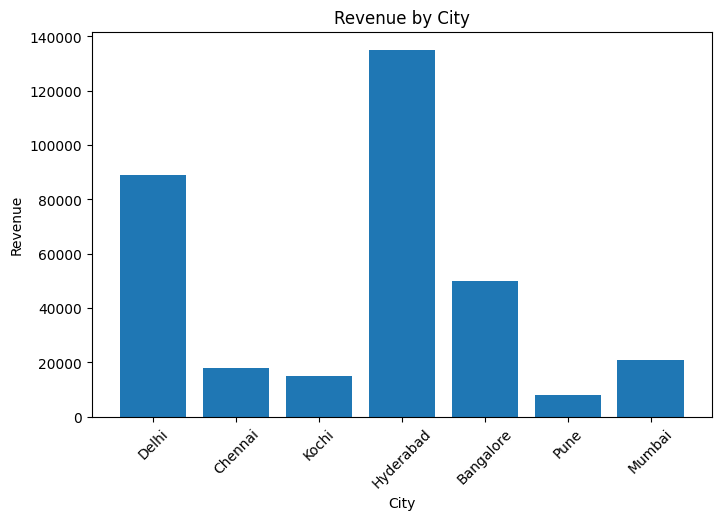

In [0]:
import matplotlib.pyplot as plt
city_df = retail_df.groupBy("city") \
.sum("revenue") \
.withColumnRenamed("sum(revenue)","Revenue")

pdf = city_df.toPandas()

plt.figure(figsize=(8,5))
plt.bar(pdf["city"], pdf["Revenue"])
plt.title("Revenue by City")
plt.xlabel("City")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

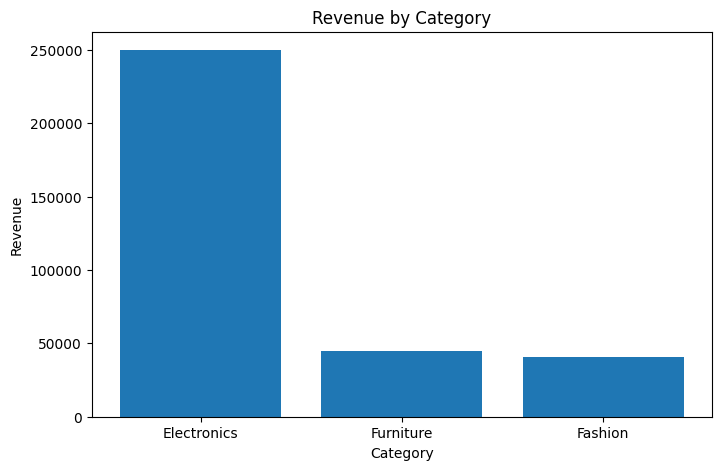

In [0]:
category_df = retail_df.groupBy("category") \
.sum("revenue") \
.withColumnRenamed("sum(revenue)","Revenue")

pdf = category_df.toPandas()

plt.figure(figsize=(8,5))
plt.bar(pdf["category"], pdf["Revenue"])
plt.title("Revenue by Category")
plt.xlabel("Category")
plt.ylabel("Revenue")
plt.show()

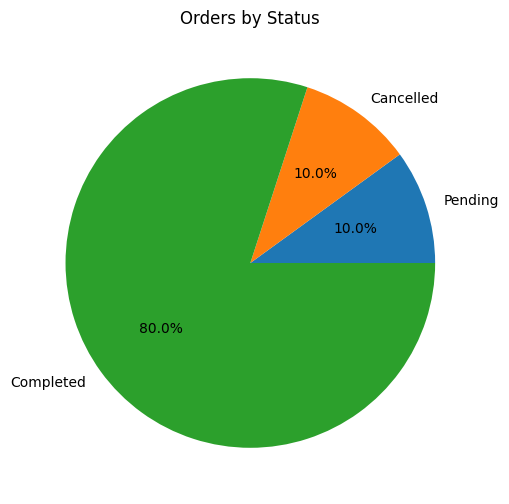

In [0]:
status_df = retail_df.groupBy("status").count()

pdf = status_df.toPandas()

plt.figure(figsize=(6,6))
plt.pie(
    pdf["count"],
    labels=pdf["status"],
    autopct="%1.1f%%"
)
plt.title("Orders by Status")
plt.show()

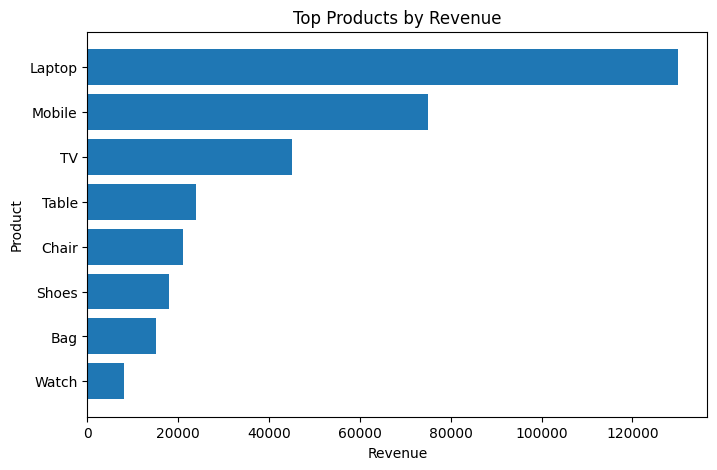

In [0]:
product_df = retail_df.groupBy("product_name") \
.sum("revenue") \
.withColumnRenamed("sum(revenue)","Revenue")

pdf = product_df.toPandas()

pdf = pdf.sort_values("Revenue")

plt.figure(figsize=(8,5))
plt.barh(pdf["product_name"], pdf["Revenue"])
plt.title("Top Products by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Product")
plt.show()

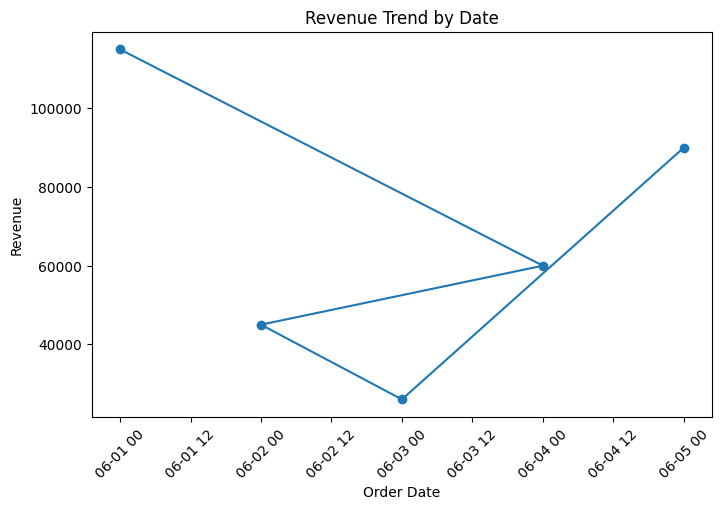

In [0]:
trend_df = retail_df.groupBy("order_date") \
.sum("revenue") \
.withColumnRenamed("sum(revenue)","Revenue")

pdf = trend_df.toPandas()

plt.figure(figsize=(8,5))
plt.plot(pdf["order_date"], pdf["Revenue"], marker="o")
plt.title("Revenue Trend by Date")
plt.xlabel("Order Date")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

In [0]:
retail_df.write \
.format("delta") \
.mode("overwrite") \
.saveAsTable("managed_retail")

In [0]:
retail_df.write \
.format("delta") \
.mode("overwrite") \
.save("abfss://unity-catalog-storage@dbstoraged3qaeocrzs7hk.dfs.core.windows.net/7405605955177719/external_retail")

In [0]:
%sql
CREATE TABLE external_retail
USING DELTA
LOCATION 'abfss://unity-catalog-storage@dbstoraged3qaeocrzs7hk.dfs.core.windows.net/7405605955177719/external_retail';

In [0]:
%sql
SELECT * FROM external_retail;

product_id,customer_id,order_id,order_date,quantity,status,customer_name,city,state,customer_type,product_name,category,unit_price,revenue,order_month,customer_segment
P101,C101,O1001,2026-06-01,1,Completed,Rahul Sharma,Hyderabad,Telangana,Premium,Laptop,Electronics,65000,65000,6,High Value
P102,C102,O1002,2026-06-01,2,Completed,Priya Reddy,Bangalore,Karnataka,Regular,Mobile,Electronics,25000,50000,6,Standard Value
P103,C103,O1003,2026-06-02,3,Pending,Amit Kumar,Mumbai,Maharashtra,Regular,Chair,Furniture,7000,21000,6,Standard Value
P104,C104,O1004,2026-06-02,2,Completed,Sneha Patel,Delhi,Delhi,Premium,Table,Furniture,12000,24000,6,High Value
P105,C105,O1005,2026-06-03,4,Cancelled,Farhan Ali,Chennai,Tamil Nadu,Regular,Shoes,Fashion,4500,18000,6,Standard Value
P106,C106,O1006,2026-06-03,1,Completed,Neha Singh,Pune,Maharashtra,Premium,Watch,Fashion,8000,8000,6,High Value
P107,C107,O1007,2026-06-04,1,Completed,Arjun Verma,Hyderabad,Telangana,Regular,TV,Electronics,45000,45000,6,Standard Value
P108,C108,O1008,2026-06-04,5,Completed,Meera Nair,Kochi,Kerala,Premium,Bag,Fashion,3000,15000,6,High Value
P102,C101,O1009,2026-06-05,1,Completed,Rahul Sharma,Hyderabad,Telangana,Premium,Mobile,Electronics,25000,25000,6,High Value
P101,C104,O1010,2026-06-05,1,Completed,Sneha Patel,Delhi,Delhi,Premium,Laptop,Electronics,65000,65000,6,High Value


In [0]:
retail_df.createOrReplaceTempView("retail_temp")